# Лабораторная работа №5: Деревья решений


### Задачи лабораторной работы

1. Загрузить датасет с оценками студентов и ввести бинарную целевую переменную «успешный / неуспешный студент».
2. Случайным образом отобрать `sqrt(n)` признаков, где `n` — общее количество доступных признаков.
3. Реализовать **дерево решений** (небинарное) по мотивам алгоритма C4.5, используя критерий разбиения **нормированный прирост информации (Gain Ratio)**.
4. Оценить качество построенной модели с использованием метрик Accuracy, Precision, Recall и матрицы ошибок.
5. Построить ROC- и PR-кривые, а также вычислить значения AUC-ROC и AUC-PR **вручную**, без готовых функций из библиотек машинного обучения.


## Шаг 1. Импорт библиотек и загрузка данных



In [2]:
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


DATA_PATH = 'lab5.csv'
df = pd.read_csv(DATA_PATH)

print('Размерность датасета (строки, столбцы):', df.shape)
df.head()

Размерность датасета (строки, столбцы): (145, 33)


,STUDENT ID,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1


## Шаг 2. Формирование целевой переменной «успешный / неуспешный студент»

По условию лабораторной работы, из исходных оценок студентов мне нужно сформировать **бинарную** целевую переменную.

Введем правило:

- студент считается **успешным**, если его итоговая оценка `GRADE` не меньше некоторого порога (по умолчанию `4`);
- иначе студент считается **неуспешным**.

Тогда новая целевая переменная `SUCCESS` определяется так:

$$
\
SUCCESS =
\begin{cases}
1, & \text{если } GRADE \ge \text{порог}, \\
0, & \text{если } GRADE < \text{порог}.
\end{cases}
\
$$

Мы вводим переменную SUCCESS, потому что алгоритм дерева решений умеет работать только с классами, а не с исходными числовыми оценками. Нам нужно превратить задачу из прогнозирования оценки в задачу бинарной классификации: определить, относится ли студент к группе успешных или нет. Такое преобразование делает постановку задачи чёткой и позволяет обучать модель, которая будет отвечать на конкретный вопрос: успешен студент или нет?

В итоге перед нами становиться задача бинарной классификации.


In [10]:
# порог успешности
success_threshold = 4

# формируем бинарной целевой переменной
df['SUCCESS'] = (df['GRADE'] >= success_threshold).astype(int)

print('Распределение успешных/неуспешных студентов:')
print(df['SUCCESS'].value_counts())
df[['STUDENT ID', 'GRADE', 'SUCCESS']].head()

Распределение успешных/неуспешных студентов:
SUCCESS
0    88
1    57
Name: count, dtype: int64


,STUDENT ID,GRADE,SUCCESS
0,STUDENT1,1,0
1,STUDENT2,1,0
2,STUDENT3,1,0
3,STUDENT4,1,0
4,STUDENT5,1,0


Из вывода программы видно, что после формирования бинарной переменной SUCCESS большинство студентов оказалось в категории неуспешных: 88 записей против 57 успешных. Это означает, что классы распределены неравномерно, и модель будет обучаться на выборке с перекосом в сторону класса 0. Также мы видим, что преобразование выполнено корректно: для каждого студента создан новый признак SUCCESS, который показывает, соответствует ли его оценка заданному порогу успешности.

## Шаг 3. Выбор признаков и разбиение на обучающую и тестовую выборки


На этом шаге я подготавливаю данные для обучения дерева решений. Сначала из набора признаков удаляются столбцы, которые не могут использоваться в качестве входных данных: идентификатор студента, фактическая итоговая оценка и целевая переменная. Эти признаки либо не несут содержательной информации, либо напрямую связаны с правильным ответом, поэтому их присутствие исказило бы работу модели. После этого я случайным образом отбираю подмножество признаков размером sqrt(n). Такое ограничение уменьшает размерность данных, снижает риск переобучения и соответствует требованиям задания, где важно изучить влияние случайности выбора признаков на работу дерева решений.

Далее данные разделяются на обучающую и тестовую части. Модель строится только на обучающей выборке, а тестовая остаётся «невидимой» до момента оценки. Это позволяет проверить, насколько хорошо алгоритм способен обобщать знания и работать с новыми студентами, которых он не видел при обучении.
По условиям задания я должен:

1. Исключить из признаков:
   - идентификатор студента (`STUDENT ID`),
   - саму итоговую оценку (`GRADE`),
   - целевую переменную (`SUCCESS`).
2. Случайным образом выбрать количество признаков, равное `sqrt(n)`, где `n` — число доступных признаков.

Это делается для того, чтобы уменьшить размерность пространства признаков, снизить риск переобучения.

### Разбиение на train/test

Реализую простую функцию `train_test_split_manual`, которая разбивает выборку на обучающую и тестовую части **без использования sklearn**.

In [6]:
def train_test_split_manual(X, y, test_size=0.3, random_state=42):
    rng = np.random.RandomState(random_state)
    n = len(y)
    indices = np.arange(n)
    rng.shuffle(indices)

    test_size_n = int(n * test_size)
    test_idx = indices[:test_size_n]
    train_idx = indices[test_size_n:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


feature_columns = [col for col in df.columns if col not in ['STUDENT ID', 'GRADE', 'SUCCESS']]

n_features = len(feature_columns)
sqrt_n = int(math.sqrt(n_features))

print('Всего признаков:', n_features)
print('sqrt(n) =', sqrt_n)

rng = np.random.RandomState(RANDOM_STATE)
selected_feature_columns = rng.choice(feature_columns, size=sqrt_n, replace=False)

print('Случайно выбранные признаки для дерева решений:')
print(selected_feature_columns)

X = df[selected_feature_columns].values
y = df['SUCCESS'].values

X_train, X_test, y_train, y_test = train_test_split_manual(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

Всего признаков: 31
sqrt(n) = 5
Случайно выбранные признаки для дерева решений:
['28' '16' '24' '18' '9']


((102, 5), (43, 5))

Из результатов видно, что после исключения недопустимых столбцов в данных осталось 31 признак, и согласно требованию задания было выбрано случайное подмножество из sqrt(n) = 5 признаков. Эти пять признаков и будут использоваться для построения дерева решений. Размерности матриц подтверждают корректность разбиения данных: обучающая выборка содержит 102 объекта, тестовая — 43, причём в обеих выборках присутствуют только выбранные пять признаков.

## Шаг 4. Теоретическая часть: энтропия и прирост информации

Дерево решений на каждом шаге выбирает признак, по которому выгоднее всего разделить текущие данные.  
Для этого я использую несколько понятий.

### 4.1. Энтропия

**Энтропия** измеряет степень неопределённости (разнообразия классов) в выборке $T$.

Если в выборке встречаются классы $C_1, \dots, C_k$, а $p_i$ — доля объектов класса $C_i$, то энтропия определяется так:

$$
\
\text{Entropy}(T) = -\sum_{i=1}^{k} p_i \log_2 p_i.
\
$$
- Если все объекты принадлежат одному классу, энтропия равна 0 (полная определённость).
- Чем равномернее распределены классы, тем выше энтропия.

### 4.2. Условная энтропия и прирост информации

Пусть я рассматриваю признак $X$, который разбивает выборку $T$ на подмножества $T_1, \dots, T_n$ по своим значениям.

**Условная энтропия** после разбиения по признаку $X$:

$$
\
\text{Info}_X(T) = \sum_{i=1}^{n} \frac{|T_i|}{|T|} \cdot \text{Entropy}(T_i).
\
$$

**Прирост информации (Information Gain)** показывает, насколько уменьшилась неопределённость после разбиения:

$$
\
\text{Gain}(X) = \text{Entropy}(T) - \text{Info}_X(T).
\
$$

### 4.3. Нормированный прирост информации (Gain Ratio)

Алгоритм C4.5 использует нормированный прирост информации, чтобы не отдавать предпочтение признакам с большим числом уникальных значений.

Сначала вводится величина:

$$
\
\text{SplitInfo}(X) = - \sum_{i=1}^{n} \frac{|T_i|}{|T|} \log_2 \left( \frac{|T_i|}{|T|} \right).
\
$$

Тогда **нормированный прирост информации** (Gain Ratio) равен:

$$
\
\text{GainRatio}(X) = \frac{\text{Gain}(X)}{\text{SplitInfo}(X)}.
\
$$
В реализации ниже я вычисляю эти величины для каждого признака и выбираю признак с максимальным Gain Ratio.


In [13]:
def entropy(labels):
    n = len(labels)
    if n == 0:
        return 0.0

    counts = Counter(labels)
    ent = 0.0
    for count in counts.values():
        p = count / n
        ent -= p * math.log2(p)
    return ent


def info_gain_ratio(X_col, y):
    base_entropy = entropy(y)
    n = len(y)

    # разбиваем по уникальным значениям признака
    values, inverse_indices = np.unique(X_col, return_inverse=True)

    conditional_entropy = 0.0
    split_info = 0.0

    for i, v in enumerate(values):
        idx = (inverse_indices == i)
        subset_y = y[idx]
        if subset_y.size == 0:
            continue

        weight = subset_y.size / n
        conditional_entropy += weight * entropy(subset_y)
        split_info -= weight * math.log2(weight)

    info_gain = base_entropy - conditional_entropy

    if split_info == 0:
        return 0.0, info_gain, split_info

    gain_ratio = info_gain / split_info
    return gain_ratio, info_gain, split_info

## Шаг 5. Реализация структуры дерева и алгоритма построения

### 5.1. Структура узла дерева

Каждый узел дерева хранит:

- `is_leaf` — признак того, является ли узел листом;
- `prediction` — предсказываемый класс (мажоритарный класс в узле);
- `feature_index` — индекс признака, по которому выполняется разбиение в этом узле;
- `children` — словарь «значение признака → дочерний узел»;
- `prob` — оценка вероятности положительного класса `SUCCESS = 1` в данном узле.

### 5.2. Рекурсивное построение дерева

Функция `build_tree` реализует построение дерева сверху вниз:

1. Выбираем мажоритарный класс в текущем узле и оцениваю долю положительного класса (это будет вероятность для ROC/PR).
2. Проверяем **критерии остановки**:
   - все объекты в узле одного класса;
   - нет доступных признаков для разбиения;
   - число объектов меньше минимального порога;
   - достигнута максимальная глубина (если задана).
3. Для каждого признака считем Gain Ratio.
4. Выбираем признак с максимальым Gain Ratio и создаю дочерние узлы по его уникальным значениям.
5. Рекурсивно продолжаю процесс для каждого дочернего узла.


In [14]:
class TreeNode:
    def __init__(self, is_leaf=False, prediction=None, feature_index=None,
                 children=None):
        self.is_leaf = is_leaf
        self.prediction = prediction
        self.feature_index = feature_index
        self.children = children if children is not None else {}


def _subset(indices, y):
    if indices is None:
        indices = np.arange(len(y))
    return indices, y[indices]


def _class_stats(subset_y):
    n_samples = subset_y.size
    counter = Counter(subset_y)
    majority_class = counter.most_common(1)[0][0]
    prob_pos = counter.get(1, 0) / n_samples if n_samples else 0.0
    return majority_class, prob_pos, counter, n_samples


def _make_leaf(prediction, prob):
    return TreeNode(is_leaf=True, prediction=prediction, prob=prob)


def _should_stop(counter, feature_indices, n_samples, depth, min_samples_split):
    if len(counter) == 1:
        return True
    if not feature_indices:
        return True
    if n_samples < min_samples_split:
        return True
    return False


def _best_split_feature(X, subset_y, indices, feature_indices):
    best_gain_ratio = -1.0
    best_feature = None

    for feat in feature_indices:
        col = X[indices, feat]
        gain_ratio, _, _ = info_gain_ratio(col, subset_y)
        if gain_ratio > best_gain_ratio:
            best_gain_ratio = gain_ratio
            best_feature = feat

    return best_feature, best_gain_ratio


def _split_child_indices(X, indices, feature, value):
    mask = (X[indices, feature] == value)
    return indices[mask]


def build_tree(X, y, feature_indices, indices=None,
               depth=0, min_samples_split=2):
    indices, subset_y = _subset(indices, y)
    if subset_y.size == 0:
        return None

    majority_class, prob_pos, counter, n_samples = _class_stats(subset_y)

    if _should_stop(counter, feature_indices, n_samples, depth,  min_samples_split):
        return _make_leaf(majority_class, prob_pos)

    best_feature, best_gain_ratio = _best_split_feature(X, subset_y, indices, feature_indices)

    if best_feature is None or best_gain_ratio <= 0:
        return _make_leaf(majority_class, prob_pos)

    node = TreeNode(
        is_leaf=False,
        prediction=majority_class,
        feature_index=best_feature,
    )

    values = np.unique(X[indices, best_feature])
    remaining_features = [f for f in feature_indices if f != best_feature]

    for v in values:
        child_indices = _split_child_indices(X, indices, best_feature, v)
        node.children[v] = (
            _make_leaf(majority_class, prob_pos)
            if child_indices.size == 0
            else build_tree(
                X, y,
                remaining_features,
                indices=child_indices,
                depth=depth + 1,
                min_samples_split=min_samples_split
            )
        )

    return node


## Шаг 6. Функции предсказания

Для применения дерева к новым объектам мне нужны функции предсказания:

- `predict_single` — проходит по дереву для одного объекта, спускаясь от корня к листу в зависимости от значений признаков;
- `predict` — обрабатывает сразу всю выборку и возвращает массив предсказанных классов и массив вероятностей положительного класса.

Если в процессе спуска по дереву встречается **новое значение признака**, которого не было в обучающей выборке, я остаюсь в текущем узле и использую его мажоритарный класс и оценку вероятности.


In [15]:
def predict_single(node, x):
    current = node
    while not current.is_leaf:
        feat_idx = current.feature_index
        value = x[feat_idx]
        if value in current.children:
            current = current.children[value]
        else:
            break
    return current.prediction, current.prob


def predict(tree, X):
    n = X.shape[0]
    preds = np.zeros(n, dtype=int)
    probs = np.zeros(n, dtype=float)
    for i in range(n):
        pred, prob = predict_single(tree, X[i])
        preds[i] = pred
        probs[i] = prob
    return preds, probs

## Шаг 7. Обучение дерева решений

На этом шаге я обучаю дерево на обучающей выборке:

- в качестве признаков используются ранее выбранные `sqrt(n)` столбцов;
- глубина дерева не ограничивается;
- минимальное число объектов для разбиения `min_samples_split` установлено равным 2.

После обучения я получаю предсказания и вероятности как для обучающей, так и для тестовой выборки.


In [16]:
feature_indices = list(range(X_train.shape[1]))

tree = build_tree(
    X_train,
    y_train,
    feature_indices,
    max_depth=None,
    min_samples_split=2,
)

y_pred_train, y_score_train = predict(tree, X_train)
y_pred_test,  y_score_test  = predict(tree, X_test)

print('Дерево решений успешно обучено.')

Дерево решений успешно обучено.


## Шаг 8. Оценка качества классификации

Для оценки качества классификации я использую следующие метрики:

### 8.1. Матрица ошибок (Confusion Matrix)

Матрица ошибок для бинарной классификации имеет вид:

|              | Предсказано 1 | Предсказано 0 |
|--------------|---------------|---------------|
| Истинный 1   | TP            | FN            |
| Истинный 0   | FP            | TN            |

Где:

- **TP** (True Positive) — истинные положительные;
- **FP** (False Positive) — ложные положительные;
- **TN** (True Negative) — истинные отрицательные;
- **FN** (False Negative) — ложные отрицательные.

### 8.2. Accuracy

Доля правильных предсказаний:
$$
\
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}.
\
$$

### 8.3. Precision

Точность положительных предсказаний:
$$
\
\text{Precision} = \frac{TP}{TP + FP}.
\
$$
### 8.4. Recall

Полнота (чувствительность):
$$
\
\text{Recall} = \frac{TP}{TP + FN}.
\
$$


In [17]:
def confusion_matrix_binary(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tp, fp, tn, fn


def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)


def precision_recall_scores(y_true, y_pred):
    tp, fp, tn, fn = confusion_matrix_binary(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return precision, recall



acc_train = accuracy_score(y_train, y_pred_train)
prec_train, rec_train = precision_recall_scores(y_train, y_pred_train)
cm_train = confusion_matrix_binary(y_train, y_pred_train)


acc_test = accuracy_score(y_test, y_pred_test)
prec_test, rec_test = precision_recall_scores(y_test, y_pred_test)
cm_test = confusion_matrix_binary(y_test, y_pred_test)

print('=== TRAIN ===')
print('Accuracy :', acc_train)
print('Precision:', prec_train)
print('Recall   :', rec_train)
print('TP, FP, TN, FN:', cm_train)

print('\n=== TEST ===')
print('Accuracy :', acc_test)
print('Precision:', prec_test)
print('Recall   :', rec_test)
print('TP, FP, TN, FN:', cm_test)

=== TRAIN ===
Accuracy : 0.8431372549019608
Precision: 0.813953488372093
Recall   : 0.813953488372093
TP, FP, TN, FN: (np.int64(35), np.int64(8), np.int64(51), np.int64(8))

=== TEST ===
Accuracy : 0.4883720930232558
Precision: 0.21428571428571427
Recall   : 0.21428571428571427
TP, FP, TN, FN: (np.int64(3), np.int64(11), np.int64(18), np.int64(11))


Из результатов видно, что на обучающей выборке дерево показывает достаточно высокие показатели качества: Accuracy около 0.84, Precision и Recall выше 0.81. Это означает, что модель хорошо подстраивается под обучающие данные и уверенно разделяет классы внутри тренировочного набора.

Однако на тестовой выборке качество резко падает: Accuracy снижается до 0.49, а Precision и Recall — до уровня около 0.21. Такой контраст между train и test указывает на выраженное переобучение модели. Дерево слишком точно подгоняется под обучающие данные, но не способно эффективно обобщать знания на новых наблюдениях. На это также указывает и структура ошибок: на тесте доля ложноположительных и ложноотрицательных решений значительно увеличивается.

Таким образом, текущее дерево недостаточно устойчиво к новым данным и требует либо ограничения глубины, либо увеличения обучающей выборки, либо повторного выбора признаков.

## Шаг 9. ROC-кривая и AUC-ROC

Для более подробной оценки качества модели построим **ROC-кривую** (Receiver Operating Characteristic).
Она показывает зависимость между:

- **TPR** — истинно-положительной долей;
- **FPR** — ложно-положительной долей,

при изменении порога классификации.

Формулы:

$$
\
\text{TPR} = \frac{TP}{TP + FN},
\quad
\text{FPR} = \frac{FP}{FP + TN}.
\
$$

Я сортирую объекты по предсказанной вероятности принадлежности к положительному классу и последовательно меняю порог, вычисляя пары (FPR, TPR).

### Площадь под ROC-кривой (AUC-ROC)

Значение **AUC (Area Under Curve)** я считаю методом трапеций:

$$
\
\text{AUC} = \sum_{i=1}^{n-1} (x_{i+1} - x_i) \cdot \frac{y_i + y_{i+1}}{2},
\
$$

где $x_i$ и $y_i$ — точки на кривой.

Ниже всё реализовано вручную.


AUC-ROC: 0.44581280788177335


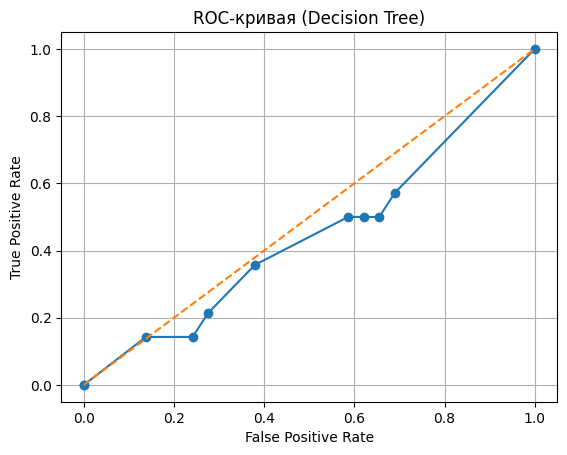

In [18]:
def roc_curve_manual(y_true, scores):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    order = np.argsort(-scores)
    y_true = y_true[order]
    scores = scores[order]
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    tps = 0
    fps = 0
    tpr_list = [0.0]
    fpr_list = [0.0]
    prev_score = None

    for i in range(len(scores)):
        if prev_score is None or scores[i] != prev_score:
            tpr_list.append(tps / P if P > 0 else 0.0)
            fpr_list.append(fps / N if N > 0 else 0.0)
            prev_score = scores[i]

        if y_true[i] == 1:
            tps += 1
        else:
            fps += 1

    tpr_list.append(tps / P if P > 0 else 0.0)
    fpr_list.append(fps / N if N > 0 else 0.0)

    return np.array(fpr_list), np.array(tpr_list)


def auc_trapezoid(x, y):
    area = 0.0
    for i in range(1, len(x)):
        width = x[i] - x[i-1]
        height = (y[i] + y[i-1]) / 2.0
        area += width * height
    return area


fpr, tpr = roc_curve_manual(y_test, y_score_test)
auc_roc = auc_trapezoid(fpr, tpr)

print('AUC-ROC:', auc_roc)

plt.figure()
plt.plot(fpr, tpr, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (Decision Tree)')
plt.grid(True)
plt.show()

На графике видно, что ROC-кривая проходит близко к диагонали случайного угадывания, а площадь под кривой (AUC ≈ 0.45) оказывается ниже значения 0.5. Это означает, что модель практически не способна различать успешных и неуспешных студентов на тестовой выборке и работает не лучше, чем случайный классификатор. Неровная форма кривой и отсутствие заметного подъёма вверх при малых значениях FPR подтверждают слабую способность дерева обобщать данные. Такой результат согласуется с низкими метриками качества на тестовой выборке и указывает на существенное переобучение модели.

## Шаг 10. PR-кривая и AUC-PR

 **Precision-Recall (PR) кривая**, которая особенно информативна при несбалансированных классах.

Строим зависимость:

- по оси X — **Recall**;
- по оси Y — **Precision**.

Для разных порогов классификации пересчитываю пары (Recall, Precision), используя формулы:

$$
\
\text{Precision} = \frac{TP}{TP + FP},
\quad
\text{Recall} = \frac{TP}{TP + FN}.
\
$$

Площадь под PR-кривой (**AUC-PR**) также вычисляется методом трапеций.


AUC-PR: 0.39775915477914164


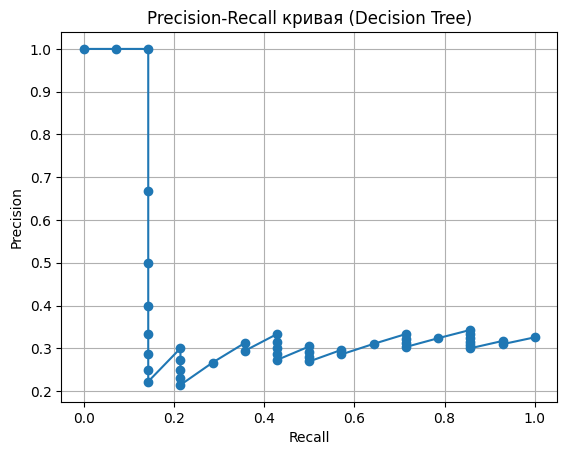

In [19]:
 def precision_recall_curve_manual(y_true, scores):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(-scores)
    y_true = y_true[order]
    scores = scores[order]

    P = np.sum(y_true == 1)
    tp = 0
    fp = 0

    precisions = []
    recalls = []

    for i in range(len(scores)):
        if y_true[i] == 1:
            tp += 1
        else:
            fp += 1

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / P if P > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)

    recalls = np.array([0.0] + recalls)
    precisions = np.array([precisions[0] if precisions else 1.0] + precisions)

    return recalls, precisions


recalls, precisions = precision_recall_curve_manual(y_test, y_score_test)
auc_pr = auc_trapezoid(recalls, precisions)

print('AUC-PR:', auc_pr)

plt.figure()
plt.plot(recalls, precisions, marker='o')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая (Decision Tree)')
plt.grid(True)
plt.show()

Precision–Recall кривая показывает, что модель справляется со своей задачей слабо: при увеличении Recall точность (Precision) быстро падает, удерживаясь на уровне около 0.25–0.35. Это говорит о том, что модель делает много ложноположительных прогнозов, особенно в тех режимах, где она пытается «поймать» больше успешных студентов. Значение AUC-PR ≈ 0.40 также подтверждает низкое качество классификации, поскольку хорошая модель должна иметь значение существенно выше среднего уровня базовой линии, равной доле положительного класса. Таким образом, по PR-кривой видно, что дерево решений не способно надёжно выделять успешных студентов и испытывает трудности в условиях несбалансированных классов.

## Шаг 11. Выводы

В ходе лабораторной работы я реализовал модель дерева решений без использования сторонних библиотек машинного обучения и последовательно воспроизвёл основные элементы алгоритма C4.5: вычисление энтропии, условной энтропии, прироста информации и нормированного прироста информации (Gain Ratio). На основе этих критериев было построено небинарное дерево решений, способное классифицировать студентов на успешных и неуспешных.

Для выполнения требований задания я случайным образом выбрал подмножество признаков размером sqrt(n) и самостоятельно реализовал разбиение данных на обучающую и тестовую выборки. На обучающей части модель показала высокие значения Accuracy, Precision и Recall, что говорит о способности дерева хорошо подстраиваться под данные, на которых оно обучается. Однако на тестовой выборке качество резко снизилось, а ROC- и PR-кривые подтвердили низкую способность модели различать классы и обобщать знания на новых данных.

Такое расхождение между train и test указывает на переобучение. Его вероятные причины — ограниченное количество данных, случайный выбор лишь небольшого числа признаков, а также слабая информативность выбранных факторов относительно целевой переменной. В результате модель оказалась недостаточно устойчивой и плохо переносит свои решения на объекты, которых не было в обучении.

Несмотря на это, работа достигла своей цели: реализован алгоритм C4.5, построено и проанализировано дерево решений, рассчитаны метрики качества, а также вручную построены ROC- и PR-кривые. Полученные результаты демонстрируют особенности поведения деревьев решений в условиях ограниченности данных и подтверждают важность выбора признаков и контроля сложности модели.
